<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [35]:
#!pip install pandas
#!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [36]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




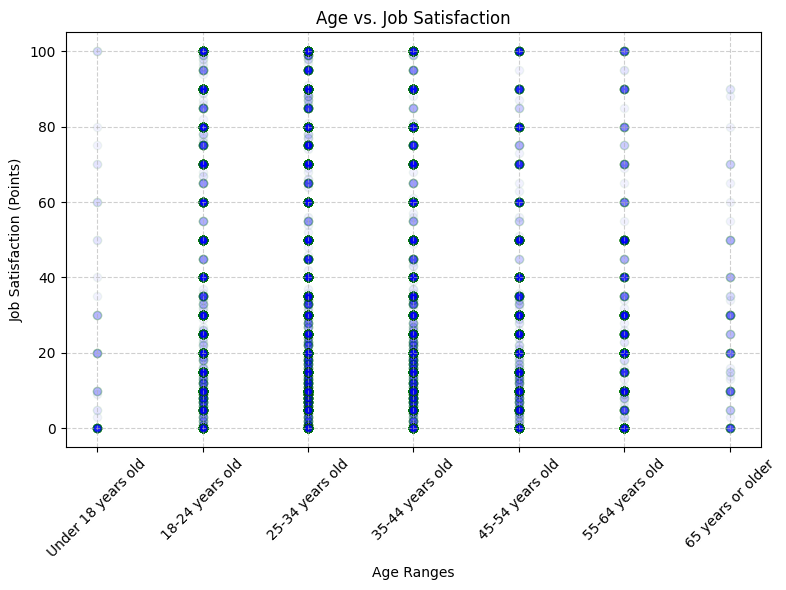

In [51]:
age_order = [
    'Under 18 years old', 
    '18-24 years old', 
    '25-34 years old', 
    '35-44 years old', 
    '45-54 years old', 
    '55-64 years old', 
    '65 years or older'
]
df_filtered = df[df['Age'] != 'Prefer not to say'].copy()
df_filtered['Age'] = pd.Categorical(df_filtered['Age'], categories=age_order, ordered=True)
df_filtered = df_filtered.sort_values('Age')

plt.figure(figsize=(8, 6))
plt.scatter(df_filtered['Age'], df_filtered['JobSatPoints_6'], alpha=0.05, color='blue', edgecolor='green', linewidths=1)

plt.title('Age vs. Job Satisfaction')
plt.xlabel('Age Ranges')
plt.ylabel('Job Satisfaction (Points)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


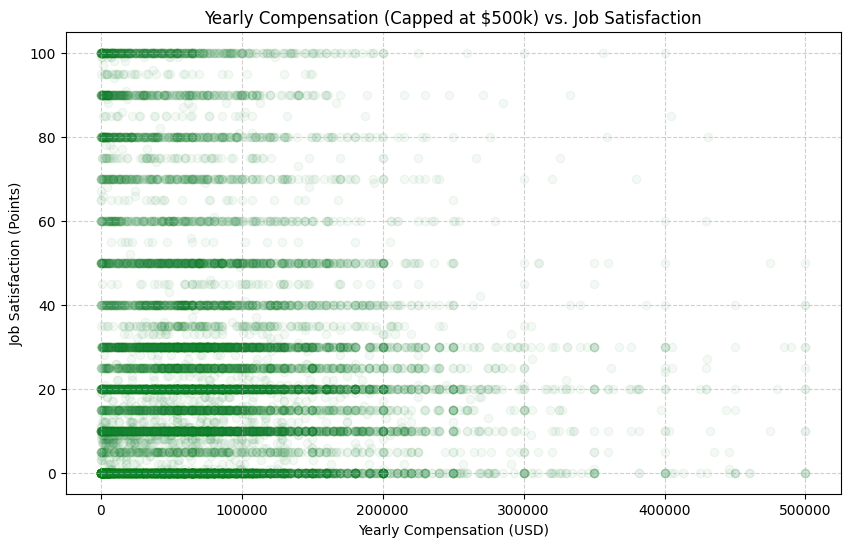

In [38]:
## Write your code here
df_filtered = df[df['ConvertedCompYearly'] <= 500000]

plt.figure(figsize=(10, 6))
plt.scatter(df_filtered['ConvertedCompYearly'], df_filtered['JobSatPoints_6'], alpha=0.05, color='seagreen', edgecolor='green', linewidths=1)

plt.title('Yearly Compensation (Capped at $500k) vs. Job Satisfaction')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Job Satisfaction (Points)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


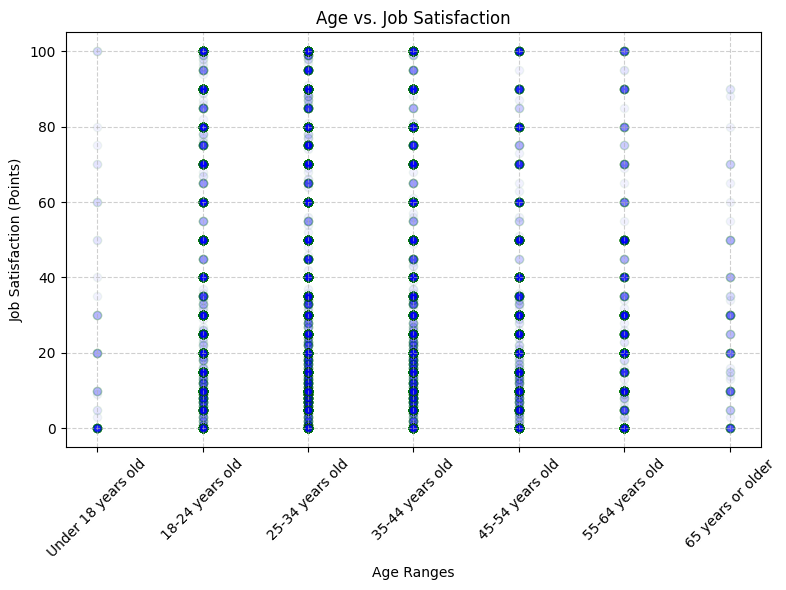

In [52]:
## Write your code here
age_order = [
    'Under 18 years old', 
    '18-24 years old', 
    '25-34 years old', 
    '35-44 years old', 
    '45-54 years old', 
    '55-64 years old', 
    '65 years or older'
]
df_filtered = df[df['Age'] != 'Prefer not to say'].copy()
df_filtered['Age'] = pd.Categorical(df_filtered['Age'], categories=age_order, ordered=True)
df_filtered = df_filtered.sort_values('Age')


plt.figure(figsize=(8, 6))
plt.scatter(df_filtered['Age'], df_filtered['JobSatPoints_6'], alpha=0.05, color='blue', edgecolor='green', linewidths=1)

plt.title('Age vs. Job Satisfaction')
plt.xlabel('Age Ranges')
plt.ylabel('Job Satisfaction (Points)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


In [45]:
## Write your code here
import numpy as np
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path)

Number of rows after cleaning: 51487
Sample of cleaned data:
     Age  YearsCodePro
1   35.0          17.0
2   45.0          27.0
6   35.0           7.0
9   35.0          11.0
11  45.0          25.0


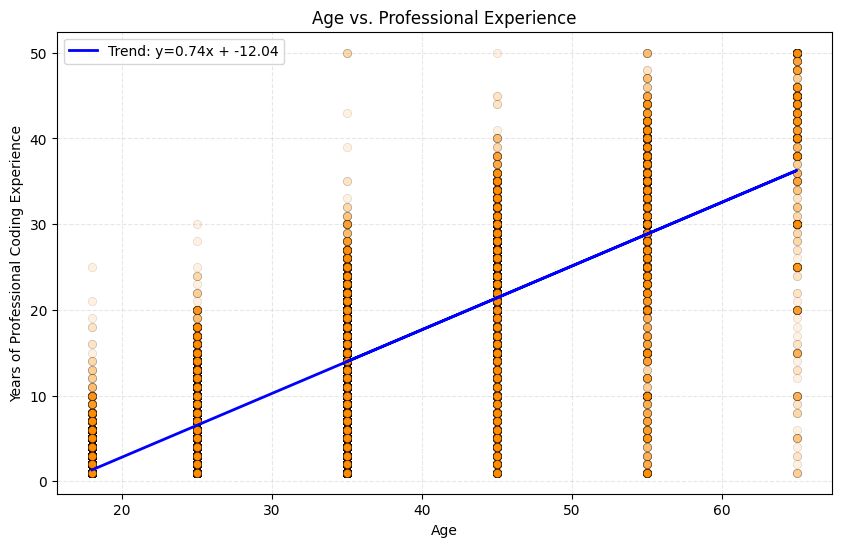

In [53]:
def clean_numeric(column):
    # Convert to string, extract first group of digits, convert back to numeric
    # Using r'(\d+)' as a raw string to avoid the SyntaxWarning
    return pd.to_numeric(df[column].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

df['Age'] = clean_numeric('Age')
df['YearsCodePro'] = clean_numeric('YearsCodePro')

# 3. Drop rows where either is still NaN
df_clean = df.dropna(subset=['Age', 'YearsCodePro'])

# 4. Check the results
print(f"Number of rows after cleaning: {len(df_clean)}")
print("Sample of cleaned data:")
print(df_clean[['Age', 'YearsCodePro']].head())

if not df_clean.empty:
    # 5. Scatter Plot & Regression
    x = df_clean['Age']
    y = df_clean['YearsCodePro']
    
    m, b = np.polyfit(x, y, 1)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.125, color='darkorange', edgecolor='black', linewidths=0.5)
    plt.plot(x, m*x + b, color='blue', linewidth=2, label=f'Trend: y={m:.2f}x + {b:.2f}')
    
    plt.title('Age vs. Professional Experience')
    plt.xlabel('Age')
    plt.ylabel('Years of Professional Coding Experience')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

In [55]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path)

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


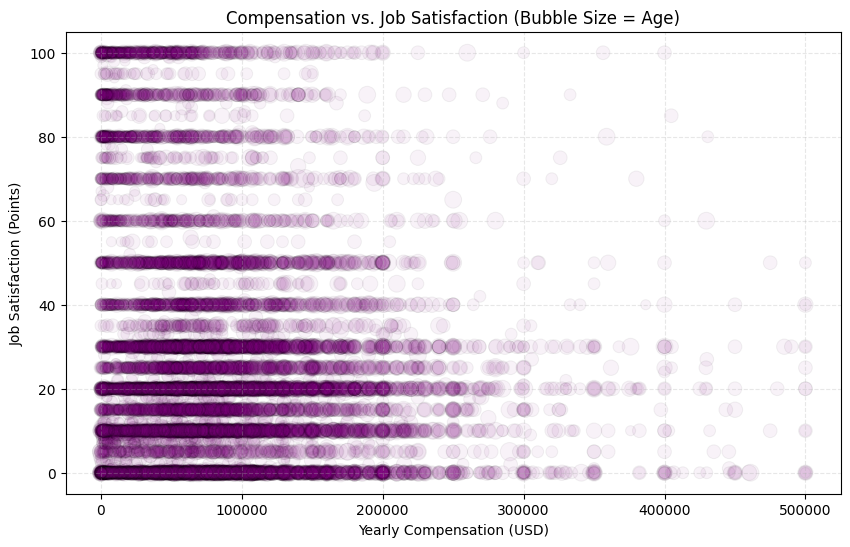

In [65]:
## Write your code here
# Numeric Midpoints for the size
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70
}
df['Age_Numeric'] = df['Age'].map(age_map)

# Clean and Cap Compensation (at $500,000 for better visibility)
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df_filtered = df[df['ConvertedCompYearly'] <= 500000].copy()
df_filtered['JobSatPoints_6'] = pd.to_numeric(df_filtered['JobSatPoints_6'], errors='coerce')

df_bubble = df_filtered.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'Age_Numeric'])

plt.figure(figsize=(10, 6))

plt.scatter(
    df_bubble['ConvertedCompYearly'], 
    df_bubble['JobSatPoints_6'], 
    s=df_bubble['Age_Numeric'] * 2.5,  # Scaling age to control bubble size
    alpha=0.05,                     
    color='purple', 
    edgecolor='black', 
    linewidths= .75
)

plt.title('Compensation vs. Job Satisfaction (Bubble Size = Age)')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Job Satisfaction (Points)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


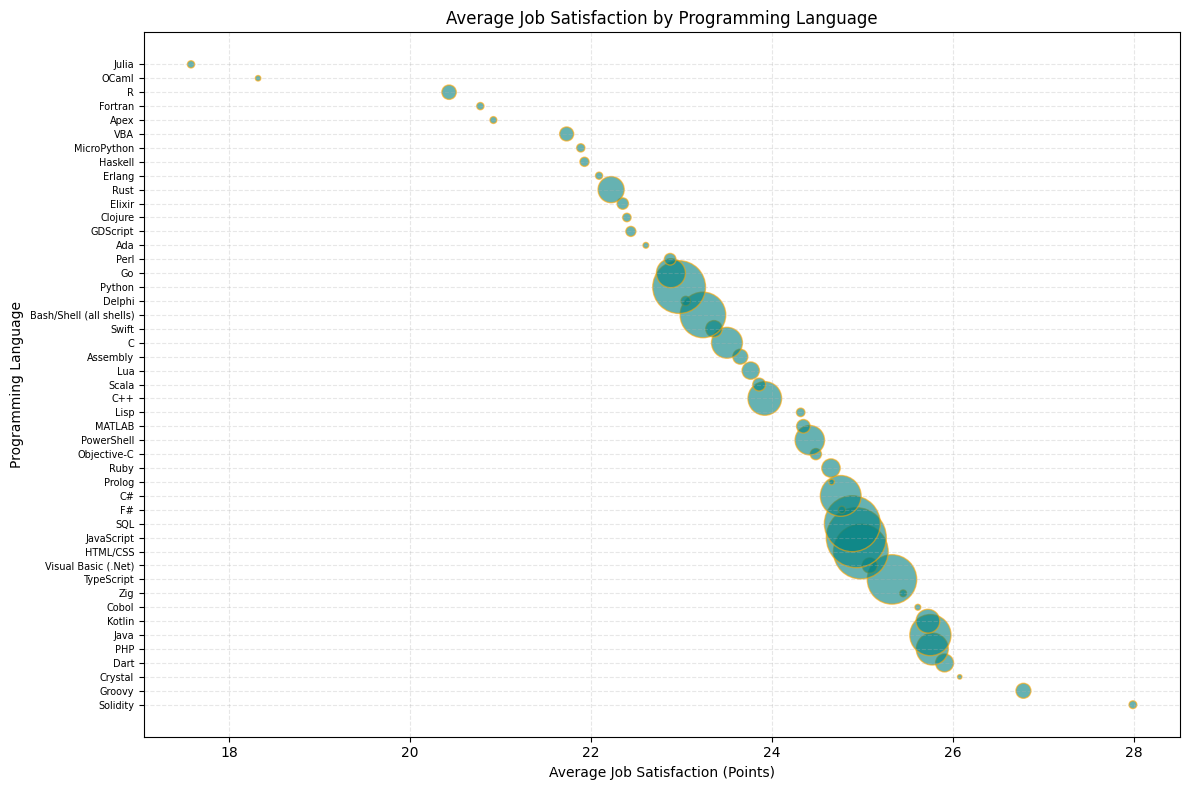

In [74]:
## Write your code here
df_lang = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna()

# Convert the string "Python;SQL" into a list ["Python", "SQL"]
df_lang['Language'] = df_lang['LanguageHaveWorkedWith'].str.split(';')

# Explode the list so each language has its own row
df_exploded = df_lang.explode('Language')

# Average satisfaction and the count (popularity) for each language
lang_stats = df_exploded.groupby('Language')['JobSatPoints_6'].agg(['mean', 'count']).reset_index()

# Filter for popularity (optional: only show languages with more than 100 responses)
lang_stats = lang_stats[lang_stats['count'] > 100].sort_values('mean', ascending=False)

# Create the Scatter Plot
plt.figure(figsize=(12, 8))
plt.scatter(lang_stats['mean'], lang_stats['Language'], 
            s=lang_stats['count']/10,  # Bubble size represents popularity
            alpha=0.6, color='teal', edgecolor='orange')

plt.title('Average Job Satisfaction by Programming Language')
plt.xlabel('Average Job Satisfaction (Points)')
plt.ylabel('Programming Language')
plt.yticks(fontsize=7)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


In [76]:
import seaborn as sns

In [88]:
## Write your code here
#df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
#df_filtered = df[df['ConvertedCompYearly'] <= 500000].dropna(subset=['Employment', 'JobSatPoints_6'])

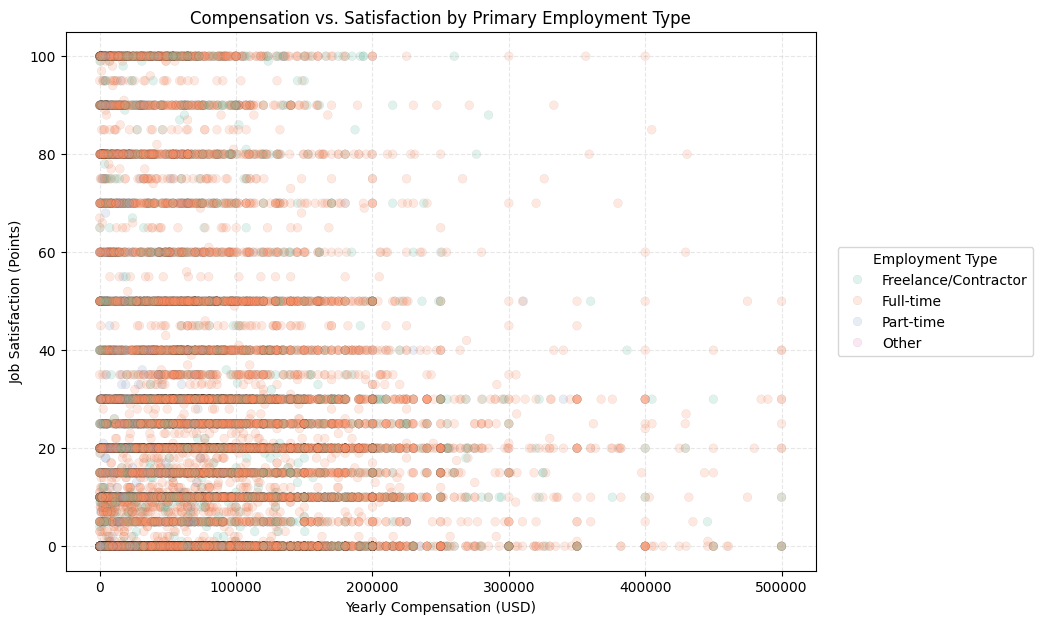

In [112]:
df_filtered = df_filtered.copy()

# Function to simplify categories
def simplify_employment(text):
    if pd.isna(text):
        return "Unknown"
    elif "Independent contractor" in text:
        return "Freelance/Contractor"
    elif "Employed, full-time" in text:
        return "Full-time"
    elif "Employed, part-time" in text:
        return "Part-time"
    elif "Student" in text:
        return "Student"
    else:
        return "Other"

# Apply the simplification
df_filtered['Employment_Simple'] = df_filtered['Employment'].apply(simplify_employment)

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_filtered, 
    x='ConvertedCompYearly', 
    y='JobSatPoints_6', 
    hue='Employment_Simple',
    s=40,  
    alpha=0.2, 
    palette='Set2', 
    edgecolor='black',
    linewidths= .125           
)

plt.legend(title='Employment Type', bbox_to_anchor=(1.02, 0.5), loc='center left')
plt.subplots_adjust(right=0.75)
plt.title('Compensation vs. Satisfaction by Primary Employment Type')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Job Satisfaction (Points)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

In [121]:
print(df_filtered.Employment.head(50))

72     Employed, full-time;Student, full-time;Indepen...
379                                  Employed, full-time
389               Employed, full-time;Student, part-time
392                                  Employed, full-time
398                                  Employed, full-time
415    Employed, full-time;Independent contractor, fr...
416    Employed, full-time;Independent contractor, fr...
417                                  Employed, full-time
423    Independent contractor, freelancer, or self-em...
424                                  Employed, full-time
425                                  Employed, full-time
426               Employed, full-time;Student, full-time
428                                  Employed, full-time
431                                  Employed, full-time
432                                  Employed, full-time
443                                  Employed, full-time
444               Employed, full-time;Student, part-time
446                            

In [114]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path)

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


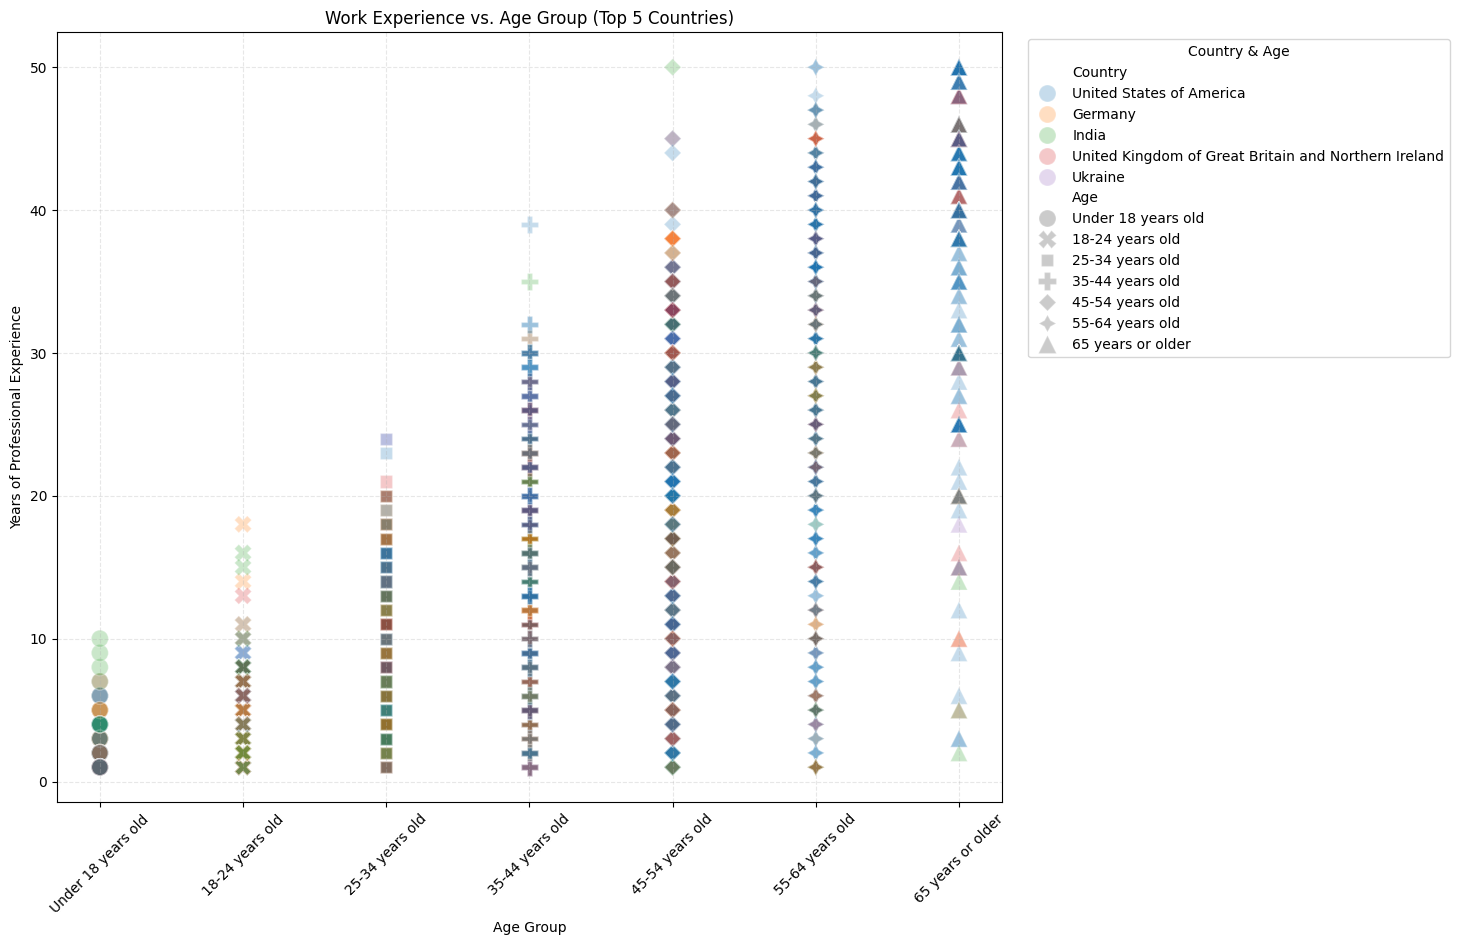

In [119]:
## Write your code here
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Age Order and convert the Age column to a Categorical type
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', 
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']

df['Age'] = pd.Categorical(df['Age'], categories=age_order, ordered=True)

# Filter for Top 5 Countries
top_countries = df['Country'].value_counts().nlargest(5).index
df_top = df[df['Country'].isin(top_countries)].copy()

plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=df_top,
    x='Age',
    y='YearsCodePro',
    hue='Country',        # Different colors for each country
    style='Age',          # Different marker shapes for age groups
    alpha=0.25,
    s=150,              
    hue_order=top_countries
)

plt.title('Work Experience vs. Age Group (Top 5 Countries)')
plt.xlabel('Age Group')
plt.ylabel('Years of Professional Experience')
plt.xticks(rotation=45)

# Move legend outside 
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Country & Age')
plt.grid(True, linestyle='--', alpha=0.3)
plt.subplots_adjust(right=0.8) # Make room for the legend

plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
